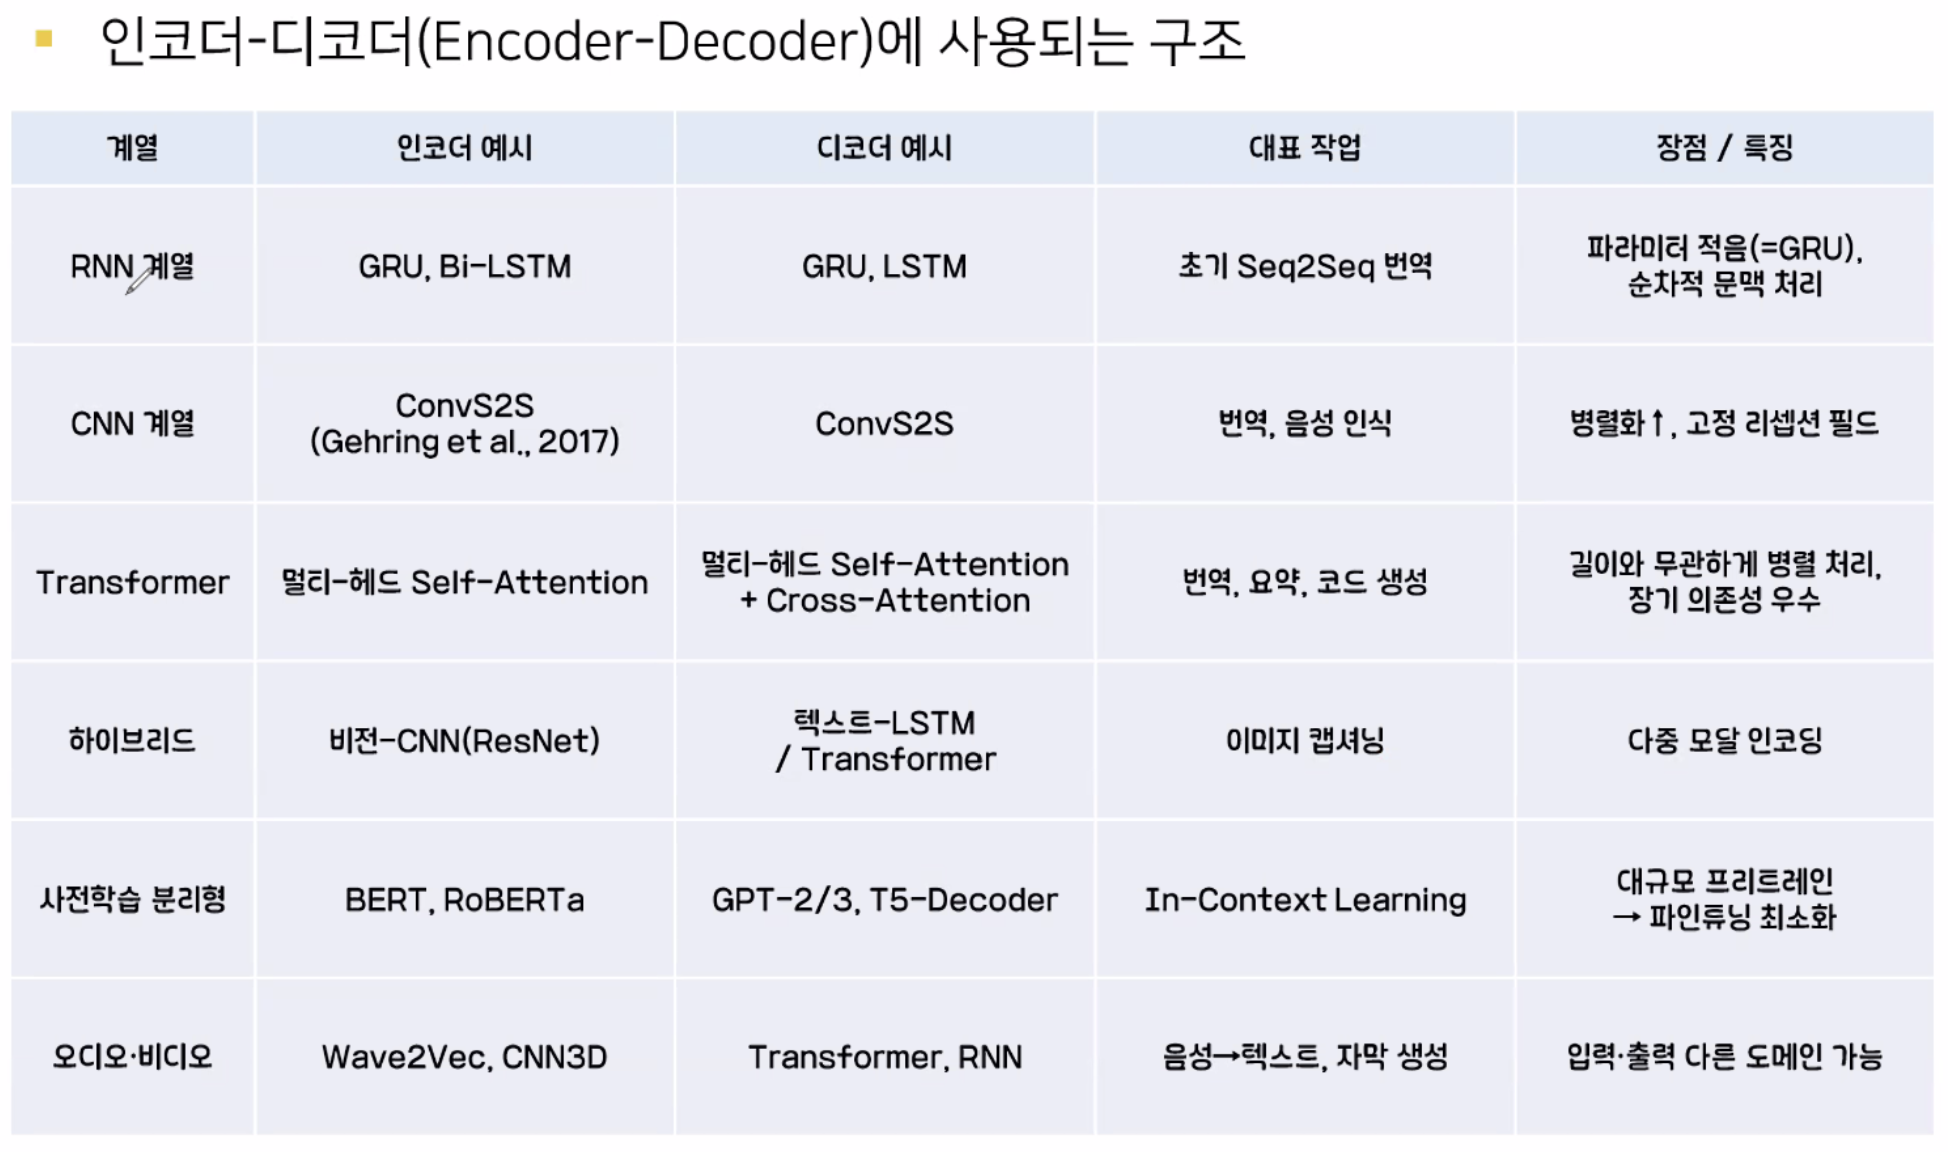

In [ ]:
# Seq2Seq 모델은 입력 문장을 벡터로 변환하는 인코더와,
# 이 벡터를 기반으로 새로운 문장을 단어 단위로 생성하는 디코더로 구성된다

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# 입력 문장과 대응하는 출력 문장 쌍
X_data = [
    [1, 2, 3], # 예 : "오늘 날씨 어때"
    [1, 4, 5], # 예 : "오늘 주가 얼마"
    [6, 7, 8]  # 예 : "날씨가 점점 따뜻해"
]

Y_data = [
    [10, 20, 30], # 예 : "It's warm"
    [10, 20, 50], # 예 : "It's high"
    [60, 30]      # 예 : "Getting warm"
]

# 입력 문장의 길이 5, 출력 문장의 길이 4
X_train = pad_sequences(X_data, maxlen=5)
Y_train = pad_sequences(Y_data, maxlen=4)

# 출력 데이터를 원-핫 인코딩 형태로 변환
# +1 한 output_vocab_size를 num_classes로 지정
input_vocab_size = np.max(X_train) + 1
output_vocab_size = int(np.max(Y_train) + 1) # np.max() : int64 => int()로 변경, 최신 keras 버전에서 int64와 int를 구분해서 받게 됨

# 원-핫 인코딩
y_train = to_categorical(Y_train, num_classes=output_vocab_size)
# print(y_train[0])

# 인코더 정의
encoder_inputs = Input(shape=(5,))
enc_emb = Embedding(input_dim=input_vocab_size, output_dim=64)(encoder_inputs)
encoder_lstm = LSTM(128, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# 디코더 정의
decoder_inputs = Input(shape=(4,))
dec_emb = Embedding(input_dim=output_vocab_size, output_dim=64)(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# 모델
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# 컴파일
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습
history = model.fit([X_train, Y_train], y_train, batch_size=2, epochs=25, validation_split=0.2)

# 시각화
y_vloss = history.history['val_loss']
y_loss = history.history['loss']
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

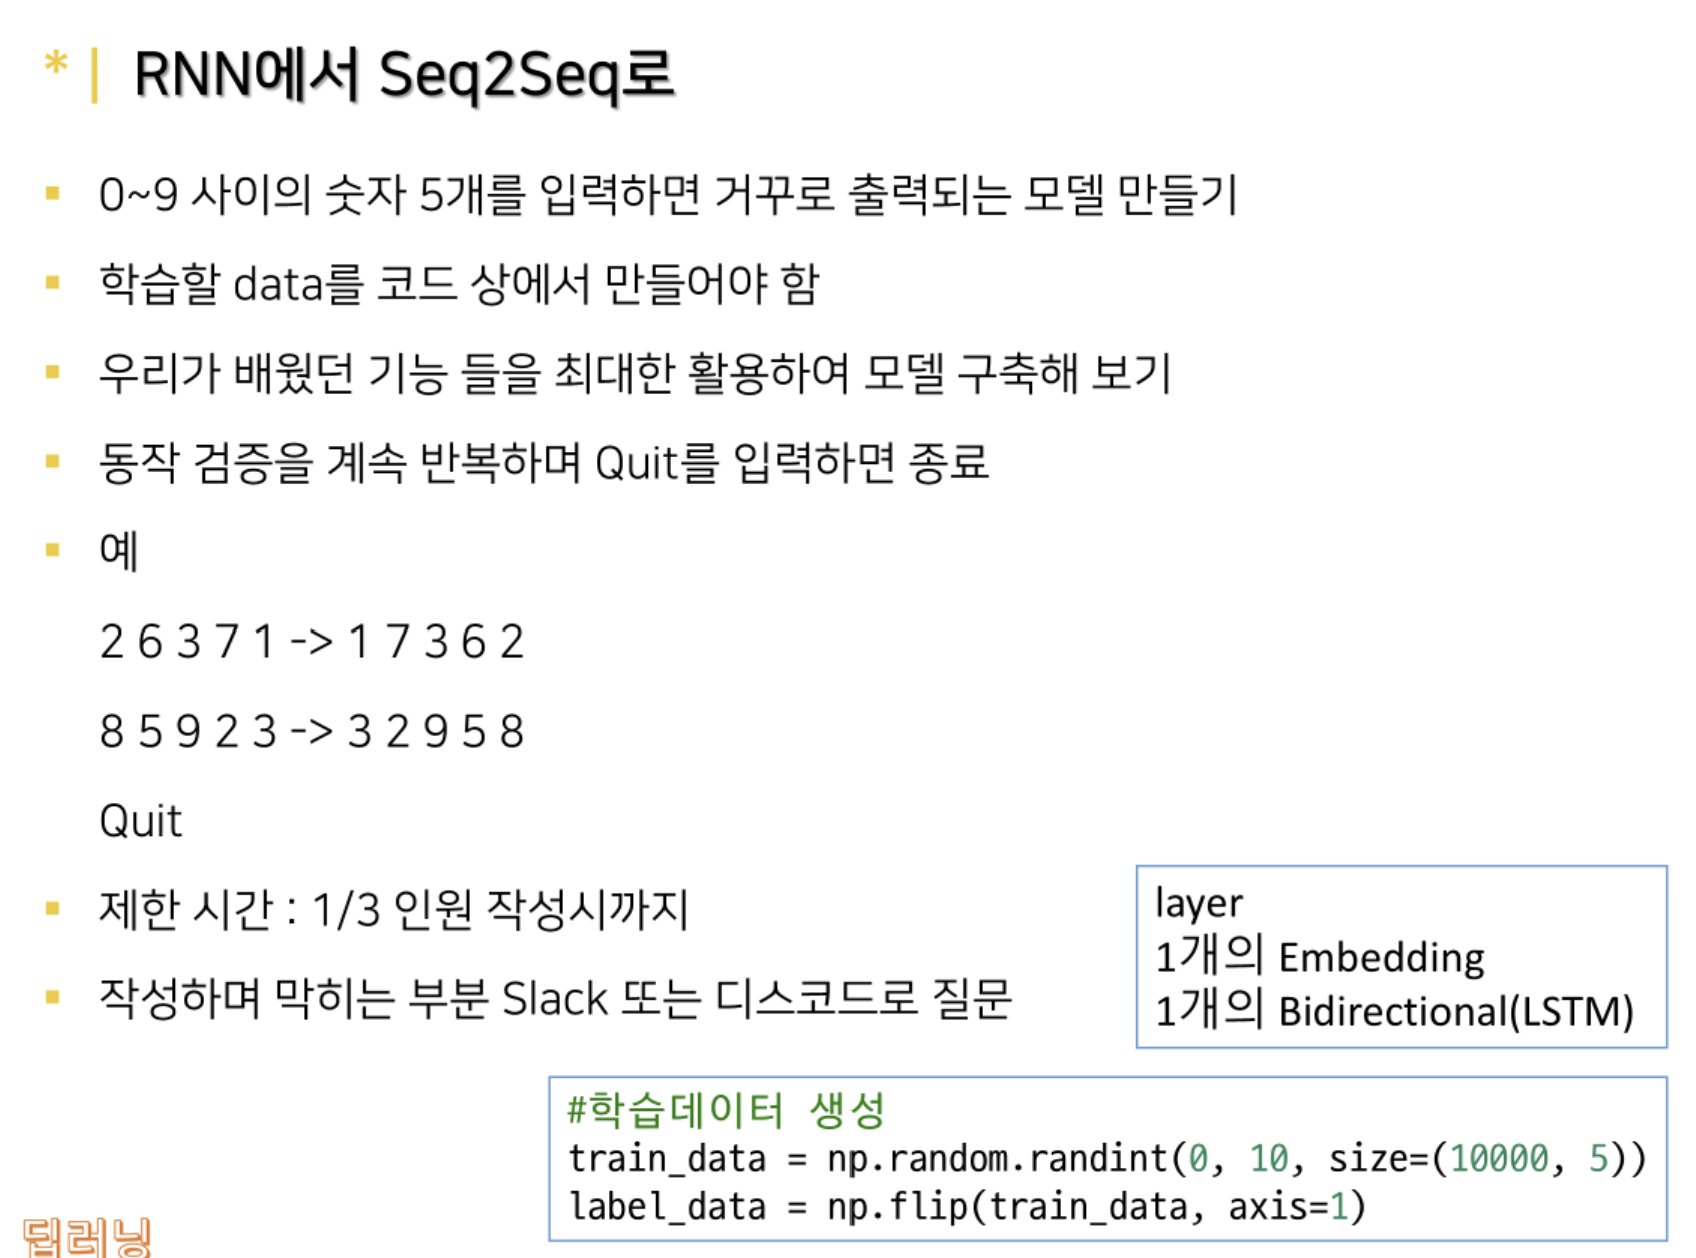

In [ ]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout, Activation

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 학습데이터 생성
train_data = np.random.randint(0, 10, size=(10000, 5))
label_data = np.flip(train_data, axis=1) # flip() : 뒤집기

# 전처리
padded_train = pad_sequences(train_data, maxlen=5)
print(padded_train[0])

# 모델링
model = Sequential()
model.add(Embedding(10, 32, input_shape=(5,)))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dense(10, activation='softmax'))
model.build(input_shape=(None, 5)) # 모델 준비 상태
model.summary()

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습
history = model.fit(padded_train, label_data, epochs=10, batch_size=32, validation_split=0.2)

loss, acc = model.evaluate(padded_train, label_data)
print(f"loss : {loss:.2f}, acc : {acc:.2f}")

# 입력받아 예측하는 프로그램
while True:
    user = input("0 ~ 9 사이의 숫자 5개 또는 Quit")
    if user == 'Quit':
        print("종료합니다")
        break

    numbers = list(map(int, user.split()))
    array_numbers = np.array([numbers])
    padded_numbers = pad_sequences(array_numbers, maxlen=5)
    prediction = model.predict(padded_numbers)
    print(np.argmax(prediction, axis=-1)[0])

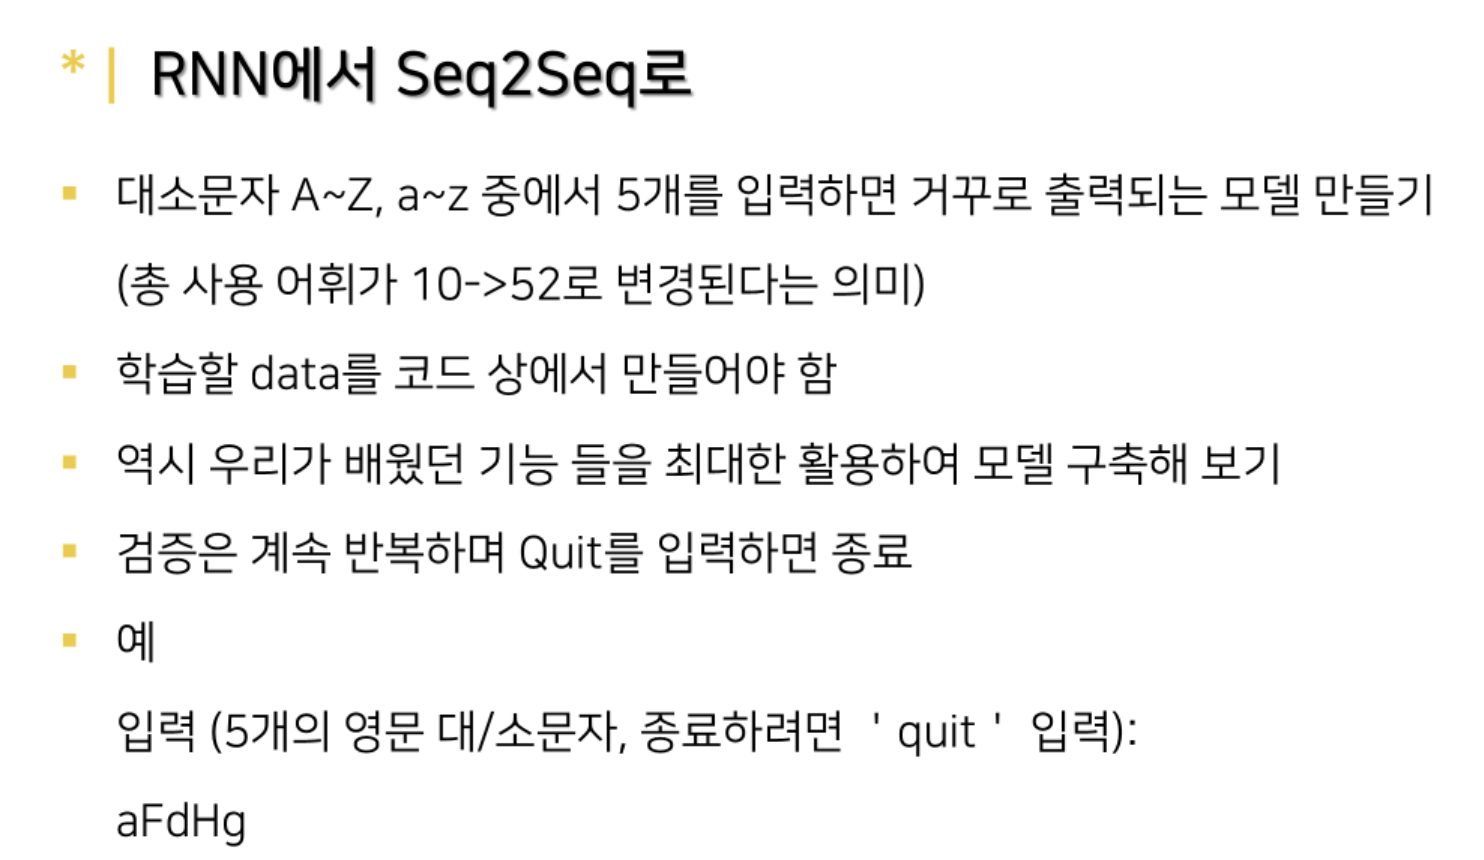

In [ ]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

cal_len = 5

# 문자와 인덱스 매핑
chars = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
num_classes = len(chars)

char_to_index = {char : idx for idx, char in enumerate(chars)} #{'A': 0, 'B': 1, 'C': 2, ..., 'Z': 25, 'a': 26, 'b': 27, ..., 'z': 51}
index_to_char = {idx : char for idx, char in enumerate(chars)} #{ 0: 'A', 1: 'B', 2: 'C', ..., 25: 'Z', 26: 'a', 27: 'b', ..., 51: 'z'}

# 학습 데이터 생성
train_data = np.random.choice(list(chars), size=(10000, cal_len))
label_data = np.flip(train_data, axis=1)

# 문자 데이터를 숫자 인덱스로 변환
train_data_indicies = np.array([[char_to_index[char] for char in seq] for seq in train_data])
label_data_indicies = np.array([[char_to_index[char] for char in seq] for seq in label_data])
# print(train_data[:4])
# print(label_data[:4])

# pad_sequences 전처리
padded_train = pad_sequences(train_data_indicies, maxlen=cal_len)
padded_labels = pad_sequences(label_data_indicies, maxlen=cal_len)

# 모델링
model = Sequential()
model.add(Embedding(num_classes, 100, input_length=cal_len))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 콜백
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 학습
history = model.fit(padded_train, padded_labels, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop])

loss, acc = model.evaluate(padded_train, padded_labels)
print(f"loss : {loss:.2f}, acc : {acc:.2f}")

# 랜덤한 영문 대소문자 5글자를 요소로 하는 20개 리스트 생성
test_data = ["".join(np.random.choice(list(chars), cal_len)) for _ in range(20)]
# 거꾸로 된 리스트 생성
expected_outputs = [s[::-1] for s in test_data]

# 모델 예측 및 정확도 계산
correct_predictions = 0
total_predictions = len(test_data)

for i, test_string in enumerate(test_data):
    numbers = [char_to_index[char] for char in test_string]
    array_numbers = np.array([numbers])
    padded_numbers = pad_sequences(array_numbers, maxlen=cal_len)

    prediction = model.predict(padded_numbers)
    predicted_indices = np.argmax(prediction, axis=-1)[0]
    predicted_chars = [index_to_char[idx] for idx in predicted_indices]
    predicted_output = "".join(predicted_chars)

    is_correct = predicted_output == expected_outputs[i]
    if is_correct:
        correct_predictions += 1
    print(f"입력 : {test_string}")
    print(f"예측된 출력 : {predicted_output}")
    print(f"예측된 출력 : {expected_outputs[i]}")
    print(f"정확 여부 : {'맞음' if is_correct else '틀림'}\n")

accuracy = correct_predictions / total_predictions
print(f"총 정확도 : {accuracy * 100:.2f}%")

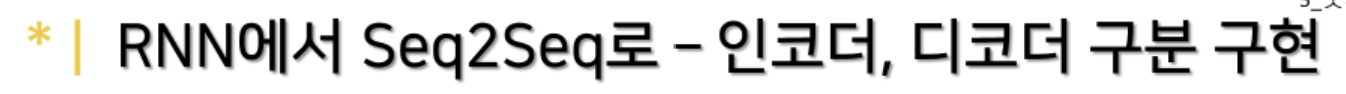

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

InputNo=10
# 데이터 생성 함수
def generate_data(num_samples):
    X = np.random.randint(0, 10, (num_samples, InputNo))
    y = np.flip(X, axis=1)
    return X, y

# 데이터 생성
num_samples = 20000
X, y = generate_data(num_samples)

# 데이터 형태 변환 (LSTM을 사용하기 위해 3D텐서로 변환)
X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape((y.shape[0], y.shape[1], 1))

# 인코더 정의
encoder_inputs = Input(shape=(InputNo, 1))
encoder = LSTM(128, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)
encoder_states = [state_h, state_c]

# 디코더 정의
decoder_inputs = Input(shape=(InputNo, 1))
decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(10, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 입력 데이터와 타겟 데이터를 동일하게 맞춤
decoder_input_data = np.zeros_like(X)

# EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 학습
model.fit([X, decoder_input_data], y, epochs=50, validation_split=0.2, callbacks=[early_stopping])

In [ ]:
# reverse 함수
def predict_reverse(input_sequence):
    input_sequence = np.array(input_sequence).reshape((1, InputNo, 1))
    decoder_input = np.zeros((1, InputNo, 1))
    predicted_sequence = model.predict([input_sequence, decoder_input])
    return np.argmax(predicted_sequence, axis=-1).reshape((InputNo,))

# 검증용 데이터 생성
test_X, test_y = generate_data(20)

# 검증
correct_predictions = 0
total_predictions = len(test_X)

for i in range(total_predictions):
    input_sequence = test_X[i]
    true_output = test_y[i].reshape(InputNo,)
    predicted_output = predict_reverse(input_sequence)

    if np.array_equal(predicted_output, true_output):
        correct_predictions += 1

    print(f"입력 : {input_sequence.reshape(InputNo,)}")
    print(f"예측된 출력 : {predicted_output}")
    print(f"실제 출력 : {true_output}")
    print(f"정확 여부 : {'맞음' if np.array_equal(predicted_output, true_output) else '틀림'}\n")

accuracy = correct_predictions / total_predictions
print(f"총 정확도 : {accuracy * 100:.2f}%")

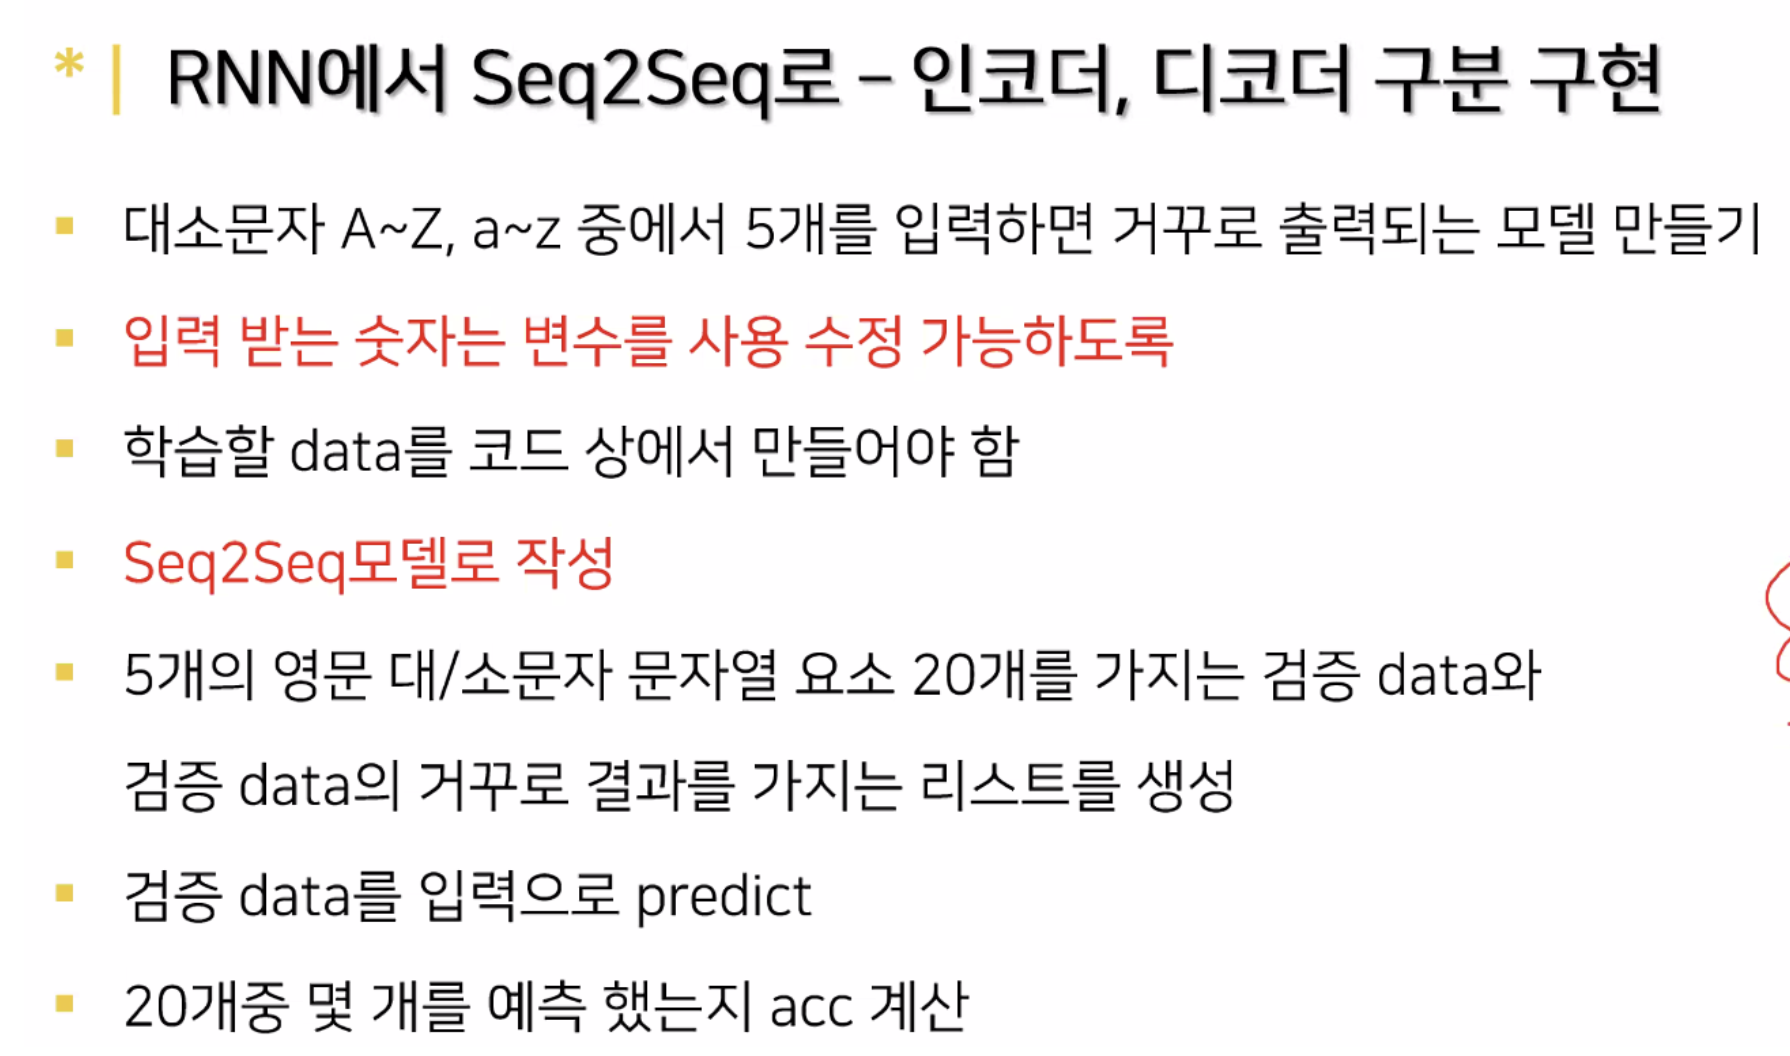

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

cal_len = 5

chars = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
num_classes = len(chars) # 모델이 분류해야 하는 클래스의 전체 갯수 : 원-핫 인코딩의 크기 + output layer 노드 갯수

char_to_index = {char : idx for idx, char in enumerate(chars)}
index_to_char = {idx : char for idx, char in enumerate(chars)}

# 데이터 생성 함수
def generate_data(num_samples):
    X = []
    y = []
    for _ in range(num_samples):
        sequence = np.random.choice(list(chars), cal_len)
        X.append([char_to_index[char] for char in sequence])
        y.append([char_to_index[char] for char in sequence[::-1]])
    return np.array(X), np.array(y)

# 데이터 생성
num_samples = 20000
X, y = generate_data(num_samples)

# 데이터 형태 변환 (LSTM을 사용하기 위해 2D -> 3D로 변환)
X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape((y.shape[0], y.shape[1], 1))

# 인코더 정의
encoder_inputs = Input(shape=(cal_len, 1))
encoder = LSTM(128, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs) # encoder_outputs와 stat_h는 동일한 값
encoder_states = [state_h, state_c]

# 디코더 정의
decoder_inputs = Input(shape=(cal_len, 1))

# return_sequences=True : 출력 시퀀스 전체를 반환해야 모든 시점에서 softmax 예측 가능
# return_state=True : 디코더도 내부 상태를 반환(추론에 필요)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
lstm_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(num_classes, activation='softmax')
# decoder_outputs는 decoder_lstm()을 거친 결과, 내부에서 전체 시퀀스 길이 shape=(cal_len, 1)만큼 반복 실행된 상태
decoder_outputs = decoder_dense(lstm_outputs)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 입력 데이터와 타겟 데이터를 동일하게 맞춤
decoder_input_data = np.zeros_like(X)
# EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 학습
model.fit([X, decoder_input_data], y, epochs=50, validation_split=0.2, callbacks=[early_stopping])

# 문자열 reverse 함수
def predict_reverse(input_sequence):
    input_sequence = np.array([char_to_index[char] for char in input_sequence]).reshape((1, cal_len, 1))
    decoder_input = np.zeros((1, cal_len, 1)) # (batch_size, 시퀀스 길이, feature)
    predicted_sequence = model.predict([input_sequence, decoder_input])
    predicted_indices = np.argmax(predicted_sequence, axis=-1).reshape((cal_len,))
    return ''.join([index_to_char[idx] for idx in predicted_indices])

# 검증용 문자열 리스트
test_strings = ["".join(np.random.choice(list(chars), cal_len)) for _ in range(30)]

# 실제 거꾸로 된 문자열 리스트
expected_outputs = [s[::-1] for s in test_strings]

# 모델 검증 및 정확도 계산
correct_predictions = 0
total_predictions = len(test_strings)

for i, test_string in enumerate(test_strings):
    predicted_output = predict_reverse(test_string)
    is_correct = predicted_output == expected_outputs[i]
    if is_correct:
        correct_predictions += 1
    print(f"입력 : {test_string}")
    print(f"예측된 출력 : {predicted_output}")
    print(f"실제 출력 : {expected_outputs[i]}")
    print(f"정확 여부 : {'맞음' if is_correct else '틀림'}\n")

accuracy = correct_predictions / total_predictions
print(f"총 정확도 : {accuracy * 100:.2f}")

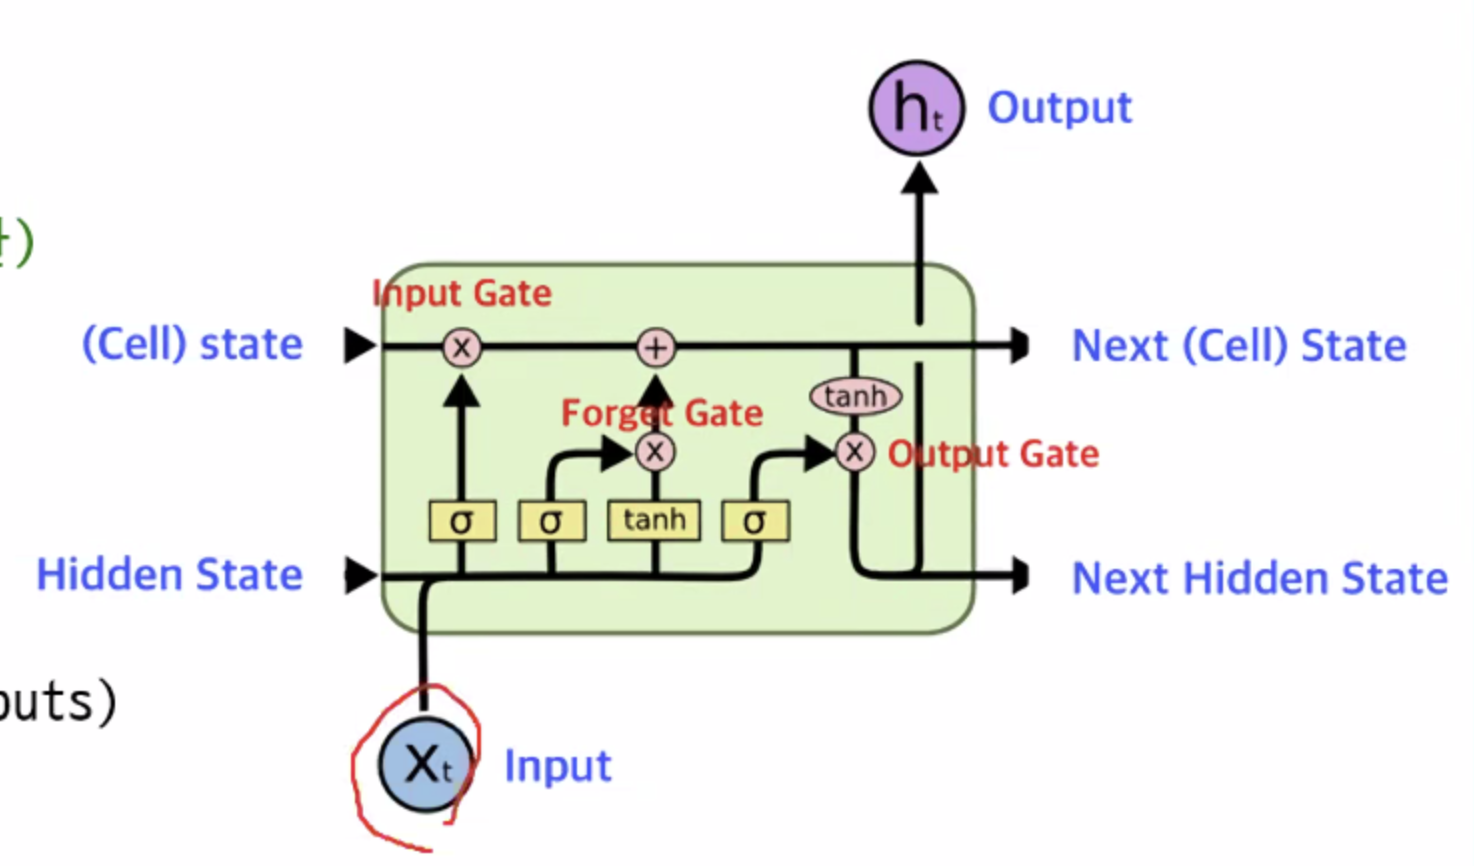

In [ ]:
# Xt 자리에 들어가는 데이터가
# 이전 시점(t-1)에서 모델이 직접 예측한 출력 값 h(t-1)을 가져와서 이번 시점의 Xt에 넣어주는지
# 아니면 사람이 알려주는 실제 정답 데이터가 들어가는지 => Teacher forcing

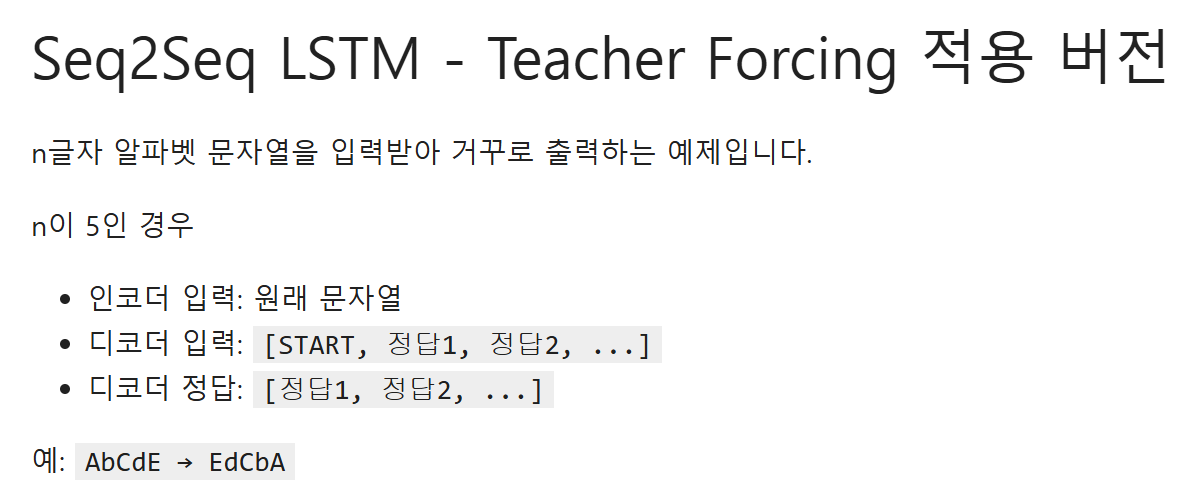

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.callbacks import EarlyStopping

cal_len = 10
num_samples = 20000

np.random.seed(42)
tf.random.set_seed(42)

# 문자 집합
chars = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
num_chars = len(chars) #52

# Seq2Seq모델의 디코더는 np.zeros((1, cal_len, 1)) 형태의, 모두 0으로 채워진 dummy 배열
# Teacher Forcing에서는 진짜 정답 단어
START_TOKEN = num_chars # 시작 인덱스

# 인코더 입력/ 디코더 입력 vocab 크기
# - 인코더 입력 : 실제 문자만 사용하므로 52개
# - 디코더 입력 : START_TOKEN까지 포함하므로 + 1(인덱스 기준)
encoder_vocab_size = num_chars
decoder_vocab_size = num_chars + 1

# 출력 클래스 수
# - 모델이 최종적으로 맞혀야 하는 것은 실제 문자 52개뿐
output_classes = num_chars

# 문자 ↔ 인덱스 매핑
char_to_index = {char : idx for idx, char in enumerate(chars)}
index_to_char = {idx : char for idx, char in enumerate(chars)}

def generate_data(num_samples): # 20000
    """
    X: 원래 문자열의 인덱스 배열
    y: 뒤집힌 문자열의 인덱스 배열
    """
    X = []
    y = []

    for _ in range(num_samples):
        sequence = np.random.choice(list(chars), cal_len) # 10

        # 입력 문자열
        X.append([char_to_index[char] for char in sequence])

        # 정답 문자열
        y.append([char_to_index[char] for char in sequence[::-1]])

    return np.array(X), np.array(y)

# 데이터 생성
X, y = generate_data(num_samples) # 20000
# print("X :", X.shape)
# print("y :", y.shape)

# Teacher Forcing 디코더 입력 생성
# 정답 y를 오른쪽으로 한칸 씩 밀어서 넣는다
#
# ex)
# y                  = [E, d, C, b, A]
# decoder_input_data = [START, E, d, C, b, A]
decoder_input_data = np.zeros_like(y)
decoder_input_data[:, 0] = START_TOKEN
decoder_input_data[:, 1:] = y[:, :-1]

# Seq2Seq모델 정의
embedding_dim = 32
hidden_units = 128

# 인코더
encoder_inputs = Input(shape=(cal_len,), name="encoder_inputs")

encoder_embedding = Embedding(
    input_dim=encoder_vocab_size,
    output_dim=embedding_dim,
    name="encoder_embedding",
)(encoder_inputs)

encoder_lstm = LSTM(
    hidden_units,
    return_state=True,
    name="encoder_lstm"
)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# 디코더
decoder_inputs = Input(shape=(cal_len,), name="decoder_inputs")

decoder_embedding = Embedding(
    input_dim=decoder_vocab_size,
    output_dim=embedding_dim,
    name="decoder_embedding"
)(decoder_inputs)

decoder_lstm = LSTM(
    hidden_units,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    output_classes,
    activation='softmax',
    name="decoder_output_dense"
)
decoder_outputs = decoder_dense(decoder_outputs)

# 전체 학습 모델
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 학습
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    [X, decoder_input_data],
    y,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

In [ ]:
# 예측 함수
def predict_reverse(input_sequence):
    """
    Teacher Forcing으로 학습한 모델을 이용해
    한 글자씩 순차적으로 예측한다.

    학습 시:
        decoder_input = [START, 정답1, 정답2, 정답3, 정답4]

    예측 시:
        decoder_input[0] = START
        1번째 글자 예측
        예측한 1번째 글자를 decoder_input[1]에 넣음
        2번째 글자 예측
        ...
    """
    # 입력 문자열을 인덱스로 변환
    input_indices = np.array(
        [char_to_index[char] for char in input_sequence]
    ).reshape((1, cal_len))

    # 디코더 입력 준비
    decoder_input = np.zeros((1, cal_len), dtype=np.int32)
    decoder_input[0, 0] = START_TOKEN

    result_indices = []

    for t in range(cal_len):
        # 현재까지 채워진 decoder_input으로 전체 시퀀스 예측
        predicted_sequence = model.predict(
            [input_indices, decoder_input],
            verbose=0
        )

        # t번째 위치의 문자 예측
        pred_idx = np.argmax(predicted_sequence[0, t])
        result_indices.append(pred_idx)

        # 다음 시점 입력으로 현재 예측값을 넣음
        if t+1 < cal_len:
           decoder_input[0, t+1] = pred_idx

    return ''.join(index_to_char[idx] for idx in result_indices)

# 검증
test_strings = [
    "".join(np.random.choice(list(chars), cal_len))
    for _ in range(30)
]

expected_outputs = [s[::-1] for s in test_strings]

correct_predictions = 0
total_predictions = len(test_strings)

for i, test_string in enumerate(test_strings):
    predicted_output = predict_reverse(test_string)
    expected_output = expected_outputs[i]

    is_correct = predicted_output == expected_output

    if is_correct:
        correct_predictions += 1

    print(f"입력: {test_string}")
    print(f"예측된 출력: {predicted_output}")
    print(f"실제 출력: {expected_output}")
    print(f"정확 여부: {'맞음' if is_correct else '틀림'}")

sequence_accuracy = correct_predictions / total_predictions

print(f"문자열 단위 정확도 : {sequence_accuracy * 100:.2f}%")
print(f"마지막 val_accuracy는 문자 단위 정확도입니다: {history.history['val_accuracy'][-1]:.4f}")